# Evaluation 1/2 — Reference Metrics (BLEU · ROUGE-L · BERTScore · readability)

One test set for everything: each system (3 tuned models + their un-tuned
instruct baselines) generates replies for the **MentalChat16K held-out test
split** exactly once, stored to `results/generations/<model>_<variant>.jsonl`
by `evaluator.py`. This notebook scores those stored generations;
`evaluate_llm_judge.ipynb` judges a sample of the SAME files — no second
evaluation dataset, no duplicate generation.

In [1]:
# Setup
import os
os.environ["PYTHONUTF8"] = "1"
os.environ["BNB_CUDA_VERSION"] = "130"  # torch is cu132; bitsandbytes tops out at cu130

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # ft root (ft_utils, config)

import json

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import textstat
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

import evaluator
import ft_utils

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# bert_score / transformers compat patch: the fast tokenizer backend dropped
# build_inputs_with_special_tokens; restore it for 2nd+ BERTScore calls.
try:
    import transformers.tokenization_utils_tokenizers as _tut
    if not hasattr(_tut.TokenizersBackend, "build_inputs_with_special_tokens"):
        def _biwst(self, token_ids_0, token_ids_1=None):
            output = [self.cls_token_id] + token_ids_0 + [self.sep_token_id]
            if token_ids_1 is not None:
                output += token_ids_1 + [self.sep_token_id]
            return output
        _tut.TokenizersBackend.build_inputs_with_special_tokens = _biwst
except ImportError:
    pass

MODELS = list(ft_utils.CFG["models"])
VARIANTS = ("tuned", "base")
RESULTS_DIR = ft_utils.RESULTS_ROOT

bed = evaluator.testbed()
print(f"Test set: {len(bed)} unique questions "
      f"({(bed['refs'].str.len() > 1).sum()} with multiple references)")
for mk in MODELS:
    print(f"  adapter {mk}: {'OK' if evaluator.adapter_available(mk) else 'MISSING - tuned pass will be skipped'}")

Test set: 1470 unique questions (7 with multiple references)
  adapter gemma2: OK
  adapter llama32: OK
  adapter qwen3: OK


In [2]:
# Generation passes — THE single generation store both notebooks use
# (cached; safe to interrupt and re-run; each pass frees its VRAM)
for mk in MODELS:
    for variant in VARIANTS:
        evaluator.generate_and_store(mk, variant)

[running] gemma2_tuned.jsonl


This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

W0802 09:44:17.821000 25212 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    1470/1470 done
          done in 90.6 min -> gemma2_tuned.jsonl
[running] gemma2_base.jsonl


...

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    1470/1470 done
          done in 92.2 min -> qwen3_tuned.jsonl
[running] qwen3_base.jsonl


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    1470/1470 done
          done in 60.8 min -> qwen3_base.jsonl


In [3]:
# Score every stored generation file -> results/scores.csv
RESCORE = False  # True to recompute even if scores.csv exists

def compute_metrics(predictions, reference_lists):
    """Multi-reference: BLEU natively; ROUGE-L and BERTScore take the best ref."""
    _, _, F1 = bert_score_fn(predictions, reference_lists, lang="en", verbose=False)
    smooth = SmoothingFunction().method1
    refs_tok = [[nltk.word_tokenize(r) for r in refs] for refs in reference_lists]
    preds_tok = [nltk.word_tokenize(p) for p in predictions]
    bleu = corpus_bleu(refs_tok, preds_tok, smoothing_function=smooth)
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rouge_l = np.mean([max(scorer.score(r, p)["rougeL"].fmeasure for r in refs)
                       for p, refs in zip(predictions, reference_lists)])
    fre = [textstat.flesch_reading_ease(p) for p in predictions if p.strip()]
    return {"bertscore_f1": round(F1.mean().item(), 4),
            "bleu": round(bleu, 4),
            "rouge_l": round(float(rouge_l), 4),
            "flesch_reading_ease": round(float(np.mean(fre)) if fre else 0.0, 2)}

scores_path = RESULTS_DIR / "scores.csv"
if scores_path.exists() and not RESCORE:
    scores = pd.read_csv(scores_path)
    print(f"Loaded cached {scores_path.name} — set RESCORE=True to recompute")
else:
    rows = []
    for mk in MODELS:
        for variant in VARIANTS:
            recs = evaluator.load_generations(mk, variant)
            if recs is None:
                continue
            print(f"Scoring {mk}_{variant} ({len(recs)} predictions)...")
            metrics = compute_metrics([r["prediction"] for r in recs],
                                      [r["refs"] for r in recs])
            rows.append({"model": mk, "variant": variant, "n": len(recs), **metrics})
    scores = pd.DataFrame(rows)
    scores.to_csv(scores_path, index=False)
    print(f"Saved {scores_path}")
scores

Scoring gemma2_tuned (1470 predictions)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Scoring gemma2_base (1470 predictions)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Scoring qwen3_base (1470 predictions)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Saved C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\scores.csv


,model,variant,n,bertscore_f1,bleu,rouge_l,flesch_reading_ease
0,gemma2,tuned,1470,0.8839,0.0867,0.2366,45.30
1,gemma2,base,1470,0.8490,0.0369,0.1740,50.11
2,llama32,tuned,1470,0.8814,0.0835,0.2270,44.15
3,llama32,base,1470,0.8561,0.0440,0.1770,51.16
4,qwen3,tuned,1470,0.8836,0.0858,0.2351,44.88
5,qwen3,base,1470,0.8519,0.0377,0.1721,54.43


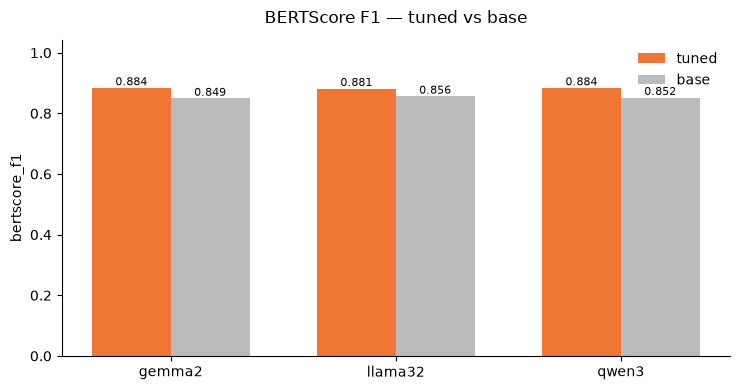

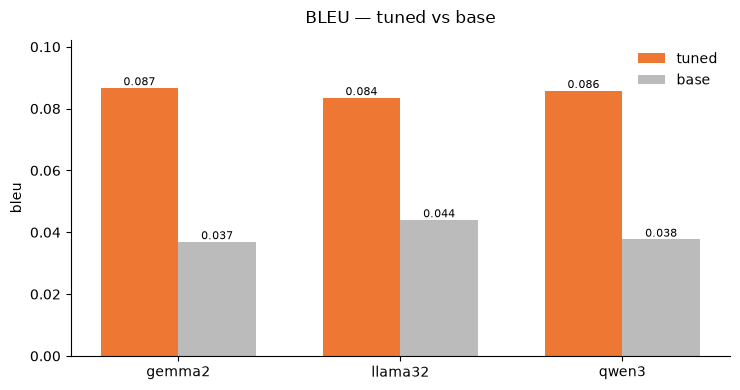

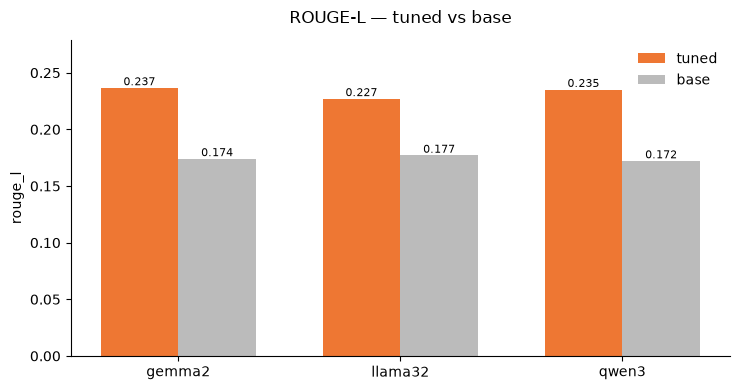

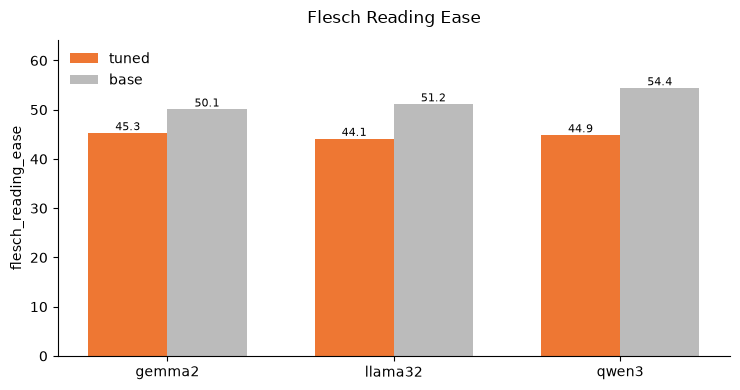

In [4]:
# Charts: models on x, one bar per variant (tuned vs base)
V_COLORS = {"tuned": "#EE7733", "base": "#BBBBBB"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

def grouped_bars(df, metric, title, fname, fmt="{:.3f}"):
    models = [m for m in MODELS if not df[df["model"] == m].empty]
    x = np.arange(len(models))
    width = 0.35
    plt.figure(figsize=(7.5, 4))
    vals_all = []
    for k, variant in enumerate(VARIANTS):
        vals = [df[(df["model"] == m) & (df["variant"] == variant)][metric].mean()
                for m in models]
        vals = [0 if np.isnan(v) else v for v in vals]
        vals_all += vals
        bars = plt.bar(x + (k - 0.5) * width, vals, width,
                       color=V_COLORS[variant], label=variant)
        plt.bar_label(bars, fmt=fmt, fontsize=8)
    hi = max(vals_all) if vals_all else 1
    plt.ylim(0, hi * 1.18)
    plt.xticks(x, models)
    plt.ylabel(metric)
    plt.title(title, fontsize=12, pad=12)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

grouped_bars(scores, "bertscore_f1", "BERTScore F1 — tuned vs base", "chart_bertscore.png")
grouped_bars(scores, "bleu", "BLEU — tuned vs base", "chart_bleu.png")
grouped_bars(scores, "rouge_l", "ROUGE-L — tuned vs base", "chart_rougel.png")
grouped_bars(scores, "flesch_reading_ease", "Flesch Reading Ease", "chart_readability.png", fmt="{:.1f}")

In [5]:
# Write results/eval_report.md
lines = ["# Evaluation Report — Counselor Fine-Tuning Study "
         "(3 models x MentalChat16K, reply-only training)", "",
         "All systems answer the SAME held-out MentalChat16K test split; the "
         "stored generations in `results/generations/` are also the input to "
         "the LLM-judge evaluation.", "",
         "## Scores", "", scores.to_markdown(index=False), ""]

tuned = scores[scores["variant"] == "tuned"]
if not tuned.empty:
    lines += ["## Winners (tuned models)", ""]
    for metric in ("bertscore_f1", "bleu", "rouge_l"):
        best = tuned.loc[tuned[metric].idxmax()]
        lines += [f"- **{metric}**: {best['model']} ({best[metric]})"]
    lines += [""]

merged = tuned.merge(scores[scores["variant"] == "base"],
                     on="model", suffixes=("_tuned", "_base"))
if not merged.empty:
    merged["delta_bertscore"] = merged["bertscore_f1_tuned"] - merged["bertscore_f1_base"]
    lines += ["## Fine-tuning lift (tuned - base, BERTScore F1)", "",
              merged[["model", "bertscore_f1_base", "bertscore_f1_tuned",
                      "delta_bertscore"]].to_markdown(index=False), ""]

lines += ["## Training manifests", ""]
for mk in MODELS:
    info_path = ft_utils.MODELS_ROOT / evaluator.DATASET_KEY / mk / "run_info.json"
    if info_path.exists():
        info = json.loads(info_path.read_text(encoding="utf-8"))
        lines += [f"- `{mk}`: {info.get('train_minutes', '?')} min, "
                  f"final train loss {info.get('final_train_loss')}, "
                  f"best eval loss {info.get('best_eval_loss')}"]

report_path = RESULTS_DIR / "eval_report.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")

Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\eval_report.md
